In [1]:
# %pip install -q "numpy<2" "scikit-surprise"

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from surprise import Dataset, Reader, SVD
from sklearn.model_selection import KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge

LOCAL_DATA_DIR = "."
KAGGLE_DATA_DIR = "/kaggle/input/datasets/truongnhatnguyen2805/movielens-v5"

if os.path.exists(os.path.join(LOCAL_DATA_DIR, "u.data")) and os.path.exists(
    os.path.join(LOCAL_DATA_DIR, "u.item")
):
    DATA_DIR = LOCAL_DATA_DIR
elif os.path.isdir(KAGGLE_DATA_DIR):
    DATA_DIR = KAGGLE_DATA_DIR
else:
    raise FileNotFoundError(
        "Không tìm thấy u.data và u.item. Hãy đặt 2 file cùng thư mục notebook hoặc mount Kaggle dataset."
    )

RANDOM_STATE = 42
N_FOLDS = 5
TOP_SVD = 150
K_WPR = 40
MIN_COMMON = 3
MIN_RATING_PROFILE = 4.0
EVAL_USERS = 100
K_NDCG_COMPARE = [1, 3, 5, 10]
K_DIV_GLOBAL_DIV = [20, 50, 100]  # Global: top-k cho Coverage / Novelty / ILD

np.random.seed(RANDOM_STATE)


In [3]:
rating_cols = ["userId", "movieId", "rating", "timestamp"]
ratings = pd.read_csv(
    os.path.join(DATA_DIR, "u.data"),
    sep="\t",
    names=rating_cols,
    engine="python",
)

item_cols = [
    "movieId", "title", "release_date", "video_release_date", "imdb_url",
    "unknown", "Action", "Adventure", "Animation", "Children", "Comedy", "Crime",
    "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "Musical", "Mystery",
    "Romance", "Sci-Fi", "Thriller", "War", "Western",
]
items = pd.read_csv(
    os.path.join(DATA_DIR, "u.item"),
    sep="|",
    names=item_cols,
    encoding="latin-1",
    engine="python",
)

genre_cols = item_cols[5:]
items[genre_cols] = items[genre_cols].fillna(0).astype(int)


def build_movie_text(row):
    genres = [g for g in genre_cols if int(row[g]) == 1]
    return f"{row['title']} {' '.join(genres)}"


items["movie_text"] = items.apply(build_movie_text, axis=1)
ratings["rating"] = ratings["rating"].astype(float)

print(f"Ratings: {ratings.shape} | Users: {ratings['userId'].nunique()} | Movies: {ratings['movieId'].nunique()}")
print(f"Items: {items.shape}")

tfidf = TfidfVectorizer(max_features=300, min_df=2, stop_words="english")
X_movies = tfidf.fit_transform(items["movie_text"])
all_movie_ids = items["movieId"].astype(int).tolist()
mid_to_row = {int(m): i for i, m in enumerate(all_movie_ids)}
print("TF-IDF (u.item):", X_movies.shape)


Ratings: (100000, 4) | Users: 943 | Movies: 1682
Items: (1682, 25)
TF-IDF (u.item): (1682, 300)


In [4]:
def ratings_dict(df):
    d = {}
    for _, row in df.iterrows():
        u, i, r = int(row["userId"]), int(row["movieId"]), float(row["rating"])
        d.setdefault(u, {})[i] = r
    return d


def user_means(rdict):
    return {u: float(np.mean(list(items_dict.values()))) for u, items_dict in rdict.items()}


def pearson_sim(rdict, mean_u, u, v, min_common=3):
    if u == v:
        return 0.0
    iu, iv = rdict.get(u, {}), rdict.get(v, {})
    common = set(iu) & set(iv)
    if len(common) < min_common:
        return 0.0
    num = sum((iu[i] - mean_u[u]) * (iv[i] - mean_u[v]) for i in common)
    du = sum((iu[i] - mean_u[u]) ** 2 for i in common)
    dv = sum((iv[i] - mean_u[v]) ** 2 for i in common)
    den = np.sqrt(du * dv)
    return 0.0 if den < 1e-12 else num / den


def precompute_user_sim(rdict, users, min_common=3):
    mean_u = user_means(rdict)
    uid_to_idx = {u: k for k, u in enumerate(users)}
    n = len(users)
    sim = np.zeros((n, n), dtype=np.float64)
    for a in range(n):
        for b in range(a + 1, n):
            s = pearson_sim(rdict, mean_u, users[a], users[b], min_common)
            sim[a, b] = sim[b, a] = s
    return sim, uid_to_idx, mean_u


def wpr_predict(u, i, rdict, mean_u, sim_row, uid_to_idx, users_list, K=40, gmean=3.5):
    candidates = []
    for v in rdict:
        if v == u or i not in rdict[v]:
            continue
        j = uid_to_idx.get(v)
        if j is None:
            continue
        s = sim_row[j]
        if s <= 0:
            continue
        rv = rdict[v][i]
        candidates.append((s, rv, mean_u[v]))
    if not candidates:
        return gmean if u not in mean_u else mean_u[u]
    candidates.sort(key=lambda x: -x[0])
    top = candidates[:K]
    num = sum(s * (rv - mb) for s, rv, mb in top)
    den = sum(abs(s) for s, _, _ in top)
    if den < 1e-12:
        return mean_u.get(u, gmean)
    base = mean_u.get(u, gmean)
    return float(np.clip(base + num / den, 1.0, 5.0))


def dcg_u_at_top_n(rank_list, test_rating_by_movie, n):
    acc = 0.0
    upto = min(n, len(rank_list))
    for i in range(1, upto + 1):
        mid = int(rank_list[i - 1])
        r = float(test_rating_by_movie.get(mid, 0.0))
        acc += (2.0**r - 1.0) / np.log(1.0 + i)
    return acc


def idcg_u_at_top_n(test_rating_by_movie, n):
    danh_sach_diem = list(test_rating_by_movie.values())
    if not danh_sach_diem:
        return 0.0
    rels = sorted(danh_sach_diem, reverse=True)[:n]
    acc = 0.0
    for i in range(1, len(rels) + 1):
        r = rels[i - 1]
        acc += (2.0**r - 1.0) / np.log(1.0 + i)
    return acc


def ndcg_u_at_top_n(rank_list, test_rating_by_movie, n):
    d = dcg_u_at_top_n(rank_list, test_rating_by_movie, n)
    ideal = idcg_u_at_top_n(test_rating_by_movie, n)
    if ideal < 1e-12:
        return np.nan
    return d / ideal


def svd_top_candidates(svd_model, raw_uid, seen_movies, topn=TOP_SVD):
    scored = []
    for m in all_movie_ids:
        if m in seen_movies:
            continue
        est = svd_model.predict(raw_uid, m).est
        scored.append((m, est))
    scored.sort(key=lambda x: -x[1])
    top = scored[:topn]
    return [m for m, _ in top], {m: s for m, s in top}


def user_profile_vector(raw_uid, train_df, min_r=MIN_RATING_PROFILE):
    subs = train_df[train_df["userId"] == raw_uid]
    hi = subs[subs["rating"] >= min_r]
    if hi.empty:
        hi = subs.nlargest(8, "rating")
    rows = [mid_to_row[int(mid)] for mid in hi["movieId"] if int(mid) in mid_to_row]
    if not rows:
        return None
    v = np.asarray(X_movies[rows].mean(axis=0)).ravel()
    n = np.linalg.norm(v)
    return (v / n) if n > 1e-12 else None


def taste_cosines(candidate_mids, profile):
    if profile is None:
        return {m: 0.0 for m in candidate_mids}
    out = {}
    for m in candidate_mids:
        r = mid_to_row.get(m)
        if r is None:
            out[m] = 0.0
            continue
        mv = np.asarray(X_movies[r].toarray()).ravel()
        nm = np.linalg.norm(mv)
        if nm < 1e-12:
            out[m] = 0.0
        else:
            out[m] = float(np.dot(profile, mv / nm))
    return out


def fit_linear_blend_model(train_df, svd_model, wpr_fn, max_users=250, max_items_per_user=20, reg=1.0):
    rng = np.random.RandomState(RANDOM_STATE)
    users = train_df["userId"].drop_duplicates().astype(int).values
    if len(users) == 0:
        return Ridge(alpha=reg)

    n_pick = min(max_users, len(users))
    picked_users = rng.choice(users, size=n_pick, replace=False)

    X, y = [], []
    for u in picked_users:
        u_df = train_df.loc[train_df["userId"] == int(u), ["movieId", "rating"]]
        if u_df.empty:
            continue
        if len(u_df) > max_items_per_user:
            u_df = u_df.sample(n=max_items_per_user, random_state=RANDOM_STATE)

        seen = set(train_df.loc[train_df["userId"] == int(u), "movieId"].astype(int).values)
        prof = user_profile_vector(int(u), train_df)

        for _, rr in u_df.iterrows():
            m = int(rr["movieId"])
            y_true = float(rr["rating"])
            s_svd = float(svd_model.predict(int(u), m).est)
            s_wpr = float(wpr_fn(int(u), m))

            r = mid_to_row.get(m)
            if prof is None or r is None:
                s_tfidf = 0.0
            else:
                mv = np.asarray(X_movies[r].toarray()).ravel()
                nm = np.linalg.norm(mv)
                s_tfidf = float(np.dot(prof, mv / nm)) if nm > 1e-12 else 0.0

            X.append([s_svd, s_tfidf, s_wpr])
            y.append(y_true)

    if len(X) == 0:
        model = Ridge(alpha=reg)
        model.coef_ = np.array([1.0, 0.0, 0.0], dtype=np.float64)
        model.intercept_ = 0.0
        return model

    model = Ridge(alpha=reg)
    model.fit(np.asarray(X, dtype=np.float64), np.asarray(y, dtype=np.float64))
    return model


def learned_linear_rank_svd_tfidf_wpr(raw_uid, candidates, svd_scores, train_df, wpr_fn, blend_model):
    prof = user_profile_vector(raw_uid, train_df)
    cos_map = taste_cosines(candidates, prof)

    feats = []
    mids = []
    for m in candidates:
        s_svd = float(svd_scores.get(m, 0.0))
        s_tfidf = float(cos_map.get(m, 0.0))
        s_wpr = float(wpr_fn(raw_uid, m))
        feats.append([s_svd, s_tfidf, s_wpr])
        mids.append(m)

    if not feats:
        return []

    pred = blend_model.predict(np.asarray(feats, dtype=np.float64))
    scored = list(zip(mids, pred.tolist()))
    scored.sort(key=lambda x: -x[1])
    return [m for m, _ in scored]


In [5]:
def recall_at_k(rank_list, relevant, k):
    if not relevant:
        return np.nan
    hit = len(set(rank_list[:k]) & relevant)
    return hit / len(relevant)


def ap_at_k(rank_list, relevant, k):
    if not relevant:
        return np.nan
    hits = 0
    sum_prec = 0.0
    for i, mid in enumerate(rank_list[:k], start=1):
        if mid in relevant:
            hits += 1
            sum_prec += hits / i
    if hits == 0:
        return 0.0
    return sum_prec / len(relevant)


def map_u_at_top_n(rank_list, relevant, n):
    return ap_at_k(rank_list, relevant, n)


def tfidf_top_candidates(raw_uid, seen_movies, train_df, topn=TOP_SVD):
    prof = user_profile_vector(raw_uid, train_df)
    if prof is None:
        return []

    scored = []
    for m in all_movie_ids:
        if m in seen_movies:
            continue
        r = mid_to_row.get(m)
        if r is None:
            continue
        mv = np.asarray(X_movies[r].toarray()).ravel()
        nm = np.linalg.norm(mv)
        if nm < 1e-12:
            cos_val = 0.0
        else:
            cos_val = float(np.dot(prof, mv / nm))
        scored.append((m, cos_val))

    scored.sort(key=lambda x: -x[1])
    return [m for m, _ in scored[:topn]]


def rerank_svd_wpr(raw_uid, candidates, wpr_fn):
    scored = [(m, wpr_fn(raw_uid, m)) for m in candidates]
    scored.sort(key=lambda x: -x[1])
    return [m for m, _ in scored]


In [6]:
MODEL_KEYS = ["SVD", "TFIDF", "SVD_WPR", "LinearLearned"]
MODEL_LABELS = [
    "SVD Only",
    "TF-IDF Only",
    "SVD + WPR",
    "Linear Learned",
]
MODEL_COLORS = ["#888888", "#F39C12", "#4A90D9", "#27AE60"]

out_dir = "/kaggle/working"

# Giống mathai-lastversion (1).ipynb : Coverage (catalog), Novelty (Laplace -log2 p), ILD (1-cos TF-IDF)
GLOBAL_METRIC_SPEC = [
    ("Coverage", "Coverage — |∪ top-k items trên các user đánh giá| / |catalog|"),
    ("Novelty", "Novelty — trung bình -log2(p), p=(count+1)/(N_train+|catalog|) Laplace"),
    ("ILD", "ILD — trung bình (1 - cosine) giữa vector TF-IDF X_movies trong top-k"),
]

GLOBAL_PLOT_YLABEL = {
    "Coverage": "Coverage (tỷ lệ catalog)",
    "Novelty": "Novelty (mean -log2 p̃)",
    "ILD": "ILD (mean 1 - cos TF-IDF)",
}


def novelty_at_k(rank_list, k, item_count_map, total_count, num_items_catalog):
    topk = rank_list[:k]
    if len(topk) == 0:
        return np.nan
    vals = []
    denom = float(total_count + num_items_catalog)
    for mid in topk:
        c = float(item_count_map.get(int(mid), 0))
        p = (c + 1.0) / denom
        vals.append(-np.log2(p))
    return float(np.mean(vals)) if vals else np.nan


def diversity_at_k(rank_list, k):
    topk = rank_list[:k]
    if len(topk) < 2:
        return np.nan
    vecs = []
    for mid in topk:
        r = mid_to_row.get(int(mid))
        if r is None:
            continue
        v = np.asarray(X_movies[r].toarray()).ravel()
        n = np.linalg.norm(v)
        if n > 1e-12:
            vecs.append(v / n)
    if len(vecs) < 2:
        return np.nan
    acc = 0.0
    cnt = 0
    for i in range(len(vecs)):
        for j in range(i + 1, len(vecs)):
            cos_ij = float(np.dot(vecs[i], vecs[j]))
            acc += (1.0 - cos_ij)
            cnt += 1
    if cnt == 0:
        return np.nan
    return float(acc / cnt)


def run_one_fold_global(fold_id, train_df, test_df):
    reader = Reader(rating_scale=(1, 5))
    train_surprise = Dataset.load_from_df(train_df[["userId", "movieId", "rating"]], reader)
    trainset = train_surprise.build_full_trainset()
    svd = SVD(n_factors=50, n_epochs=25, lr_all=0.005, reg_all=0.02, random_state=RANDOM_STATE)
    svd.fit(trainset)

    rdict = ratings_dict(train_df)
    gmean = float(train_df["rating"].mean())
    users_sorted = sorted(rdict.keys())
    sim_mat, uid_to_idx, mean_u = precompute_user_sim(rdict, users_sorted, MIN_COMMON)

    pop_counts = train_df["movieId"].value_counts()
    total_ratings = int(len(train_df))
    num_items_catalog = int(len(all_movie_ids))

    def wpr_score(u, movie_id):
        if u not in uid_to_idx:
            return gmean
        sim_row = sim_mat[uid_to_idx[u]]
        return wpr_predict(u, movie_id, rdict, mean_u, sim_row, uid_to_idx, users_sorted, K=K_WPR, gmean=gmean)

    blend_model = fit_linear_blend_model(train_df, svd, wpr_score)

    cand_users = test_df["userId"].unique()
    n_pick = min(EVAL_USERS, len(cand_users))
    rng = np.random.RandomState(RANDOM_STATE + fold_id)
    eval_users = rng.choice(cand_users, size=n_pick, replace=False)

    coverage_sets = {mk: {kk: set() for kk in K_DIV_GLOBAL_DIV} for mk in MODEL_KEYS}
    novelty_vals = {mk: {kk: [] for kk in K_DIV_GLOBAL_DIV} for mk in MODEL_KEYS}
    ild_vals = {mk: {kk: [] for kk in K_DIV_GLOBAL_DIV} for mk in MODEL_KEYS}

    rows = []
    for u in eval_users:
        seen = set(train_df.loc[train_df["userId"] == u, "movieId"].astype(int))
        relevant = set(test_df.loc[(test_df["userId"] == u) & (test_df["rating"] >= 4.0), "movieId"].astype(int))
        relevant = {int(x) for x in relevant if int(x) not in seen}
        if len(relevant) < 1:
            continue

        tu = test_df.loc[test_df["userId"] == u, ["movieId", "rating"]]
        test_rating_by_movie = dict(zip(tu["movieId"].astype(int), tu["rating"].astype(float)))

        rank_svd, svd_scores = svd_top_candidates(svd, int(u), seen, TOP_SVD)
        rank_tfidf = tfidf_top_candidates(int(u), seen, train_df, TOP_SVD)
        rank_svd_wpr = rerank_svd_wpr(int(u), rank_svd, wpr_score)

        candidates_linear = list(dict.fromkeys(rank_svd + rank_tfidf))
        for m in candidates_linear:
            if m not in svd_scores:
                svd_scores[m] = float(svd.predict(int(u), m).est)

        rank_linear = learned_linear_rank_svd_tfidf_wpr(
            int(u), candidates_linear, svd_scores, train_df, wpr_score, blend_model
        )

        all_ranks = {
            "SVD": rank_svd,
            "TFIDF": rank_tfidf,
            "SVD_WPR": rank_svd_wpr,
            "LinearLearned": rank_linear,
        }

        row = {"fold": fold_id, "userId": int(u), "|rel|": len(relevant)}
        for kk in K_NDCG_COMPARE:
            for mk in MODEL_KEYS:
                rank = all_ranks[mk]
                row[f"NDCG@{kk} {mk}"] = ndcg_u_at_top_n(rank, test_rating_by_movie, kk)
                row[f"Recall@{kk} {mk}"] = recall_at_k(rank, relevant, kk)
                row[f"MAP@{kk} {mk}"] = map_u_at_top_n(rank, relevant, kk)
        for k_div in K_DIV_GLOBAL_DIV:
            for mk in MODEL_KEYS:
                rank = all_ranks[mk]
                topk = rank[:k_div]
                coverage_sets[mk][k_div].update(int(m) for m in topk)
                nov = novelty_at_k(rank, k_div, pop_counts, total_ratings, num_items_catalog)
                if not np.isnan(nov):
                    novelty_vals[mk][k_div].append(float(nov))
                div = diversity_at_k(rank, k_div)
                if not np.isnan(div):
                    ild_vals[mk][k_div].append(float(div))
                row[f"Novelty@{k_div} {mk}"] = nov
                row[f"ILD@{k_div} {mk}"] = div
        rows.append(row)

    fold_extra = {}
    for mk in MODEL_KEYS:
        for k_div in K_DIV_GLOBAL_DIV:
            cov = len(coverage_sets[mk][k_div]) / max(1, num_items_catalog)
            nov_mean = float(np.mean(novelty_vals[mk][k_div])) if novelty_vals[mk][k_div] else np.nan
            ild_mean = float(np.mean(ild_vals[mk][k_div])) if ild_vals[mk][k_div] else np.nan
            fold_extra[f"Coverage@{k_div} {mk}"] = cov
            fold_extra[f"Novelty@{k_div} {mk}"] = nov_mean
            fold_extra[f"ILD@{k_div} {mk}"] = ild_mean

    return pd.DataFrame(rows), fold_extra


kf2 = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
idx2 = np.arange(len(ratings))

global_fold_metrics = []
global_fold_summaries = []

for fold_id, (train_idx, test_idx) in enumerate(kf2.split(idx2)):
    train_k = ratings.iloc[train_idx].reset_index(drop=True)
    test_k = ratings.iloc[test_idx].reset_index(drop=True)
    print(f"--- Global diversity | Fold {fold_id + 1}/{N_FOLDS} | train {len(train_k)} | test {len(test_k)} ---")
    mdf, fold_extra = run_one_fold_global(fold_id + 1, train_k, test_k)
    global_fold_metrics.append(mdf)
    acc_nov_ild_cols = [
        c
        for c in mdf.columns
        if c.startswith(("NDCG@", "Recall@", "MAP@", "Novelty@", "ILD@"))
    ]
    umean = mdf[acc_nov_ild_cols].mean(numeric_only=True) if not mdf.empty and acc_nov_ild_cols else pd.Series()
    global_fold_summaries.append({"fold": fold_id + 1, **umean.to_dict(), **fold_extra})

global_per_fold_df = pd.DataFrame(global_fold_summaries)
global_full = pd.concat(global_fold_metrics, ignore_index=True)

display(global_per_fold_df)

global_agg_cols = [c for c in global_per_fold_df.columns if c != "fold"]
gbl_mean = global_per_fold_df[global_agg_cols].mean()
gbl_std = global_per_fold_df[global_agg_cols].std()
gbl_summary = pd.DataFrame({"mean": gbl_mean, "std": gbl_std})
display(gbl_summary)

if os.path.isdir(out_dir):
    global_per_fold_df.to_csv(os.path.join(out_dir, "global_diversity_fold_means.csv"), index=False)
    gbl_summary.to_csv(os.path.join(out_dir, "global_diversity_summary.csv"))
    global_full.to_csv(os.path.join(out_dir, "global_diversity_all_users.csv"), index=False)
    print("Saved CSV", out_dir)


--- Global diversity | Fold 1/5 | train 80000 | test 20000 ---
--- Global diversity | Fold 2/5 | train 80000 | test 20000 ---
--- Global diversity | Fold 3/5 | train 80000 | test 20000 ---
--- Global diversity | Fold 4/5 | train 80000 | test 20000 ---
--- Global diversity | Fold 5/5 | train 80000 | test 20000 ---


,fold,NDCG@1 SVD,Recall@1 SVD,MAP@1 SVD,NDCG@1 TFIDF,Recall@1 TFIDF,MAP@1 TFIDF,NDCG@1 SVD_WPR,Recall@1 SVD_WPR,MAP@1 SVD_WPR,...,Coverage@100 SVD,Coverage@20 TFIDF,Coverage@50 TFIDF,Coverage@100 TFIDF,Coverage@20 SVD_WPR,Coverage@50 SVD_WPR,Coverage@100 SVD_WPR,Coverage@20 LinearLearned,Coverage@50 LinearLearned,Coverage@100 LinearLearned
0,1,0.081303,0.010077,0.010077,0.038512,0.006858,0.006858,0.010204,0.000378,0.000378,...,0.249108,0.201546,0.319263,0.441141,0.096314,0.157551,0.222354,0.104637,0.192033,0.285375
1,2,0.119056,0.006751,0.006751,0.053719,0.005847,0.005847,0.020619,0.001179,0.001179,...,0.272889,0.233056,0.353151,0.451249,0.116528,0.172414,0.243757,0.122473,0.202140,0.290725
2,3,0.061290,0.002331,0.002331,0.036602,0.007833,0.007833,0.000000,0.000000,0.000000,...,0.282996,0.224138,0.346017,0.464328,0.109394,0.170036,0.240785,0.117717,0.190250,0.294887
3,4,0.081477,0.006416,0.006416,0.024099,0.000733,0.000733,0.020619,0.002320,0.002320,...,0.243757,0.238407,0.348989,0.473246,0.109394,0.171225,0.231272,0.104637,0.193222,0.284185
4,5,0.138482,0.008849,0.008849,0.072184,0.011270,0.011270,0.010101,0.000722,0.000722,...,0.264566,0.213436,0.328181,0.445303,0.095719,0.168847,0.232461,0.107015,0.200951,0.298454


,mean,std
NDCG@1 SVD,0.096321,0.031494
Recall@1 SVD,0.006885,0.002959
MAP@1 SVD,0.006885,0.002959
NDCG@1 TFIDF,0.045023,0.018469
Recall@1 TFIDF,0.006508,0.003819
...,...,...
Coverage@50 SVD_WPR,0.168014,0.005999
Coverage@100 SVD_WPR,0.234126,0.008464
Coverage@20 LinearLearned,0.111296,0.008264
Coverage@50 LinearLearned,0.195719,0.005439


Coverage — |∪ top-k items trên các user đánh giá| / |catalog|


,SVD Only,TF-IDF Only,SVD + WPR,Linear Learned
k,,,,
20,0.1156,0.2221,0.1055,0.1113
50,0.1848,0.3391,0.1680,0.1957
100,0.2627,0.4551,0.2341,0.2907


,SVD Only,TF-IDF Only,SVD + WPR,Linear Learned
k,,,,
20,0.0062,0.0149,0.0091,0.0083
50,0.0111,0.0146,0.0060,0.0054
100,0.0163,0.0134,0.0085,0.0061


Novelty — trung bình -log2(p), p=(count+1)/(N_train+|catalog|) Laplace


,SVD Only,TF-IDF Only,SVD + WPR,Linear Learned
k,,,,
20,9.4147,11.5299,10.3179,10.4640
50,9.6830,11.8160,10.1131,10.2969
100,9.9372,11.8721,10.0741,10.2518


,SVD Only,TF-IDF Only,SVD + WPR,Linear Learned
k,,,,
20,0.0334,0.0432,0.0786,0.1522
50,0.0426,0.0281,0.0554,0.0790
100,0.0439,0.0342,0.0447,0.0409


ILD — trung bình (1 - cosine) giữa vector TF-IDF X_movies trong top-k


,SVD Only,TF-IDF Only,SVD + WPR,Linear Learned
k,,,,
20,0.9278,0.3322,0.9264,0.8707
50,0.9385,0.4281,0.9369,0.8987
100,0.9425,0.5453,0.9421,0.9141


,SVD Only,TF-IDF Only,SVD + WPR,Linear Learned
k,,,,
20,0.0014,0.0166,0.0024,0.0039
50,0.0009,0.0097,0.0012,0.0038
100,0.0004,0.0077,0.0009,0.0033


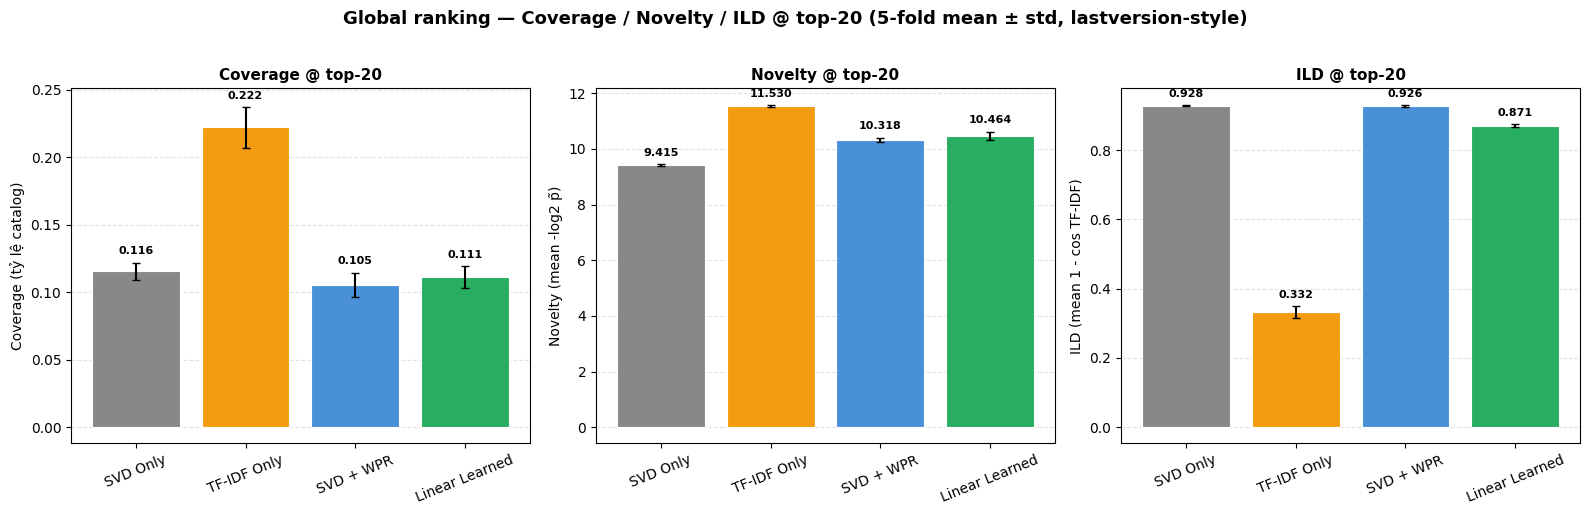

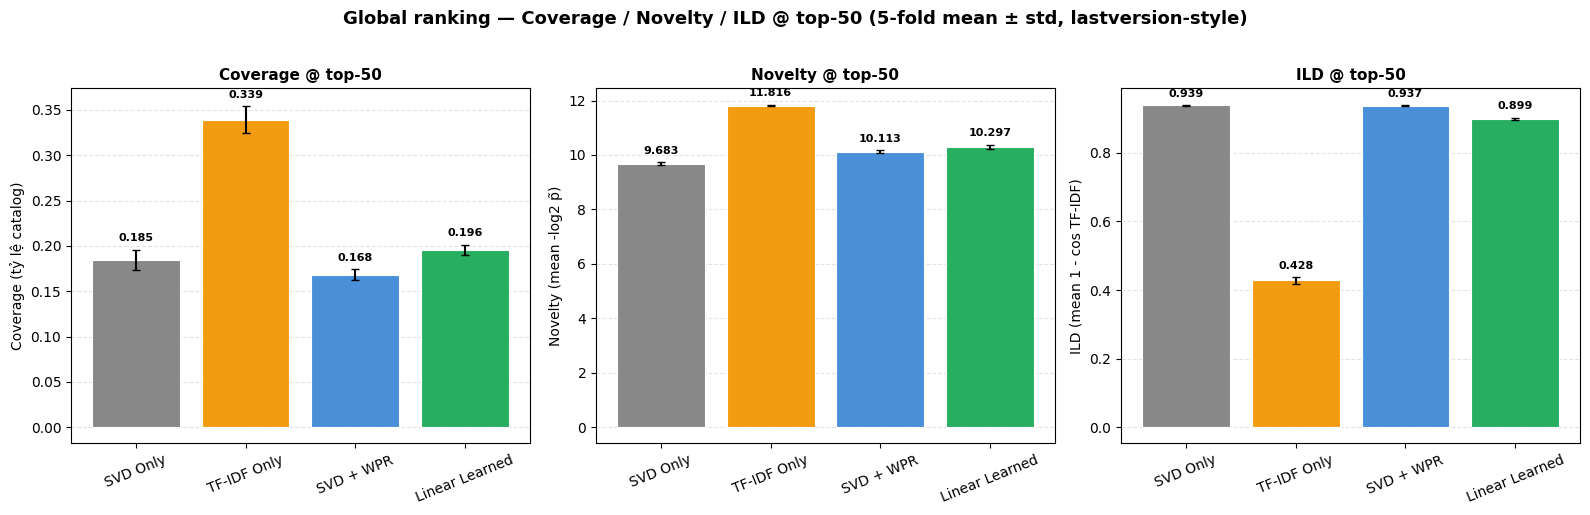

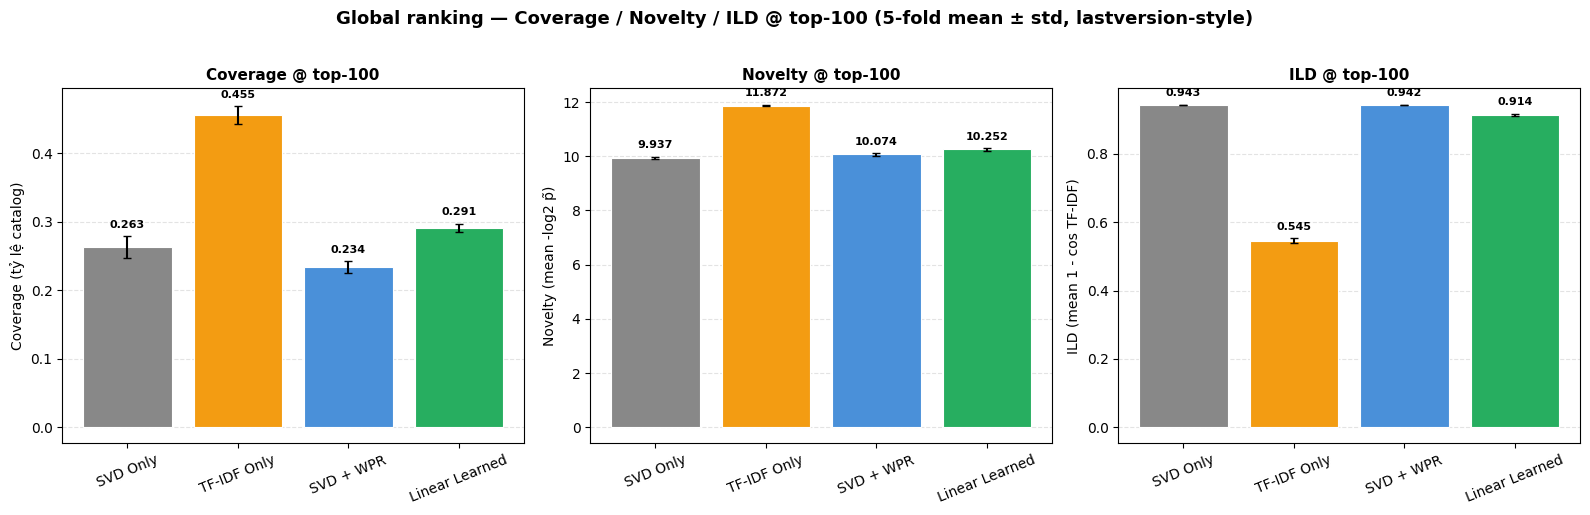

SVD Only                            | @20: Coverage=0.116, Novelty=9.415, ILD=0.928 | @50: Coverage=0.185, Novelty=9.683, ILD=0.939 | @100: Coverage=0.263, Novelty=9.937, ILD=0.943
TF-IDF Only                         | @20: Coverage=0.222, Novelty=11.530, ILD=0.332 | @50: Coverage=0.339, Novelty=11.816, ILD=0.428 | @100: Coverage=0.455, Novelty=11.872, ILD=0.545
SVD + WPR                           | @20: Coverage=0.105, Novelty=10.318, ILD=0.926 | @50: Coverage=0.168, Novelty=10.113, ILD=0.937 | @100: Coverage=0.234, Novelty=10.074, ILD=0.942
Linear Learned                      | @20: Coverage=0.111, Novelty=10.464, ILD=0.871 | @50: Coverage=0.196, Novelty=10.297, ILD=0.899 | @100: Coverage=0.291, Novelty=10.252, ILD=0.914
NDCG — Global (mean / std trên 5 fold)


,SVD Only,TF-IDF Only,SVD + WPR,Linear Learned
k,,,,
1,0.0963,0.0450,0.0123,0.1205
3,0.0836,0.0388,0.0204,0.1033
5,0.0822,0.0407,0.0268,0.0974
10,0.0809,0.0480,0.0419,0.0968


,SVD Only,TF-IDF Only,SVD + WPR,Linear Learned
k,,,,
1,0.0315,0.0185,0.0086,0.0318
3,0.0194,0.0098,0.0076,0.0289
5,0.0142,0.0080,0.0047,0.0224
10,0.0147,0.0073,0.0053,0.0175


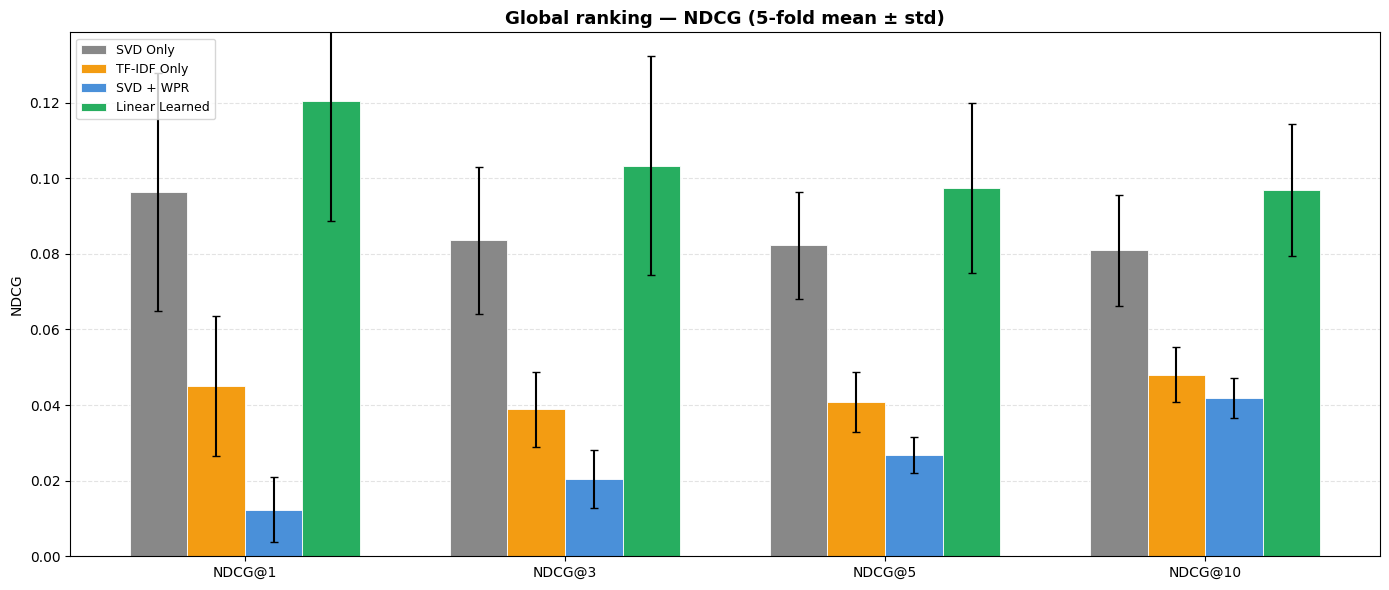

Recall — Global (mean / std trên 5 fold)


,SVD Only,TF-IDF Only,SVD + WPR,Linear Learned
k,,,,
1,0.0069,0.0065,0.0009,0.0145
3,0.0183,0.0142,0.0062,0.0318
5,0.0301,0.0239,0.0158,0.0434
10,0.0515,0.0454,0.0425,0.0683


,SVD Only,TF-IDF Only,SVD + WPR,Linear Learned
k,,,,
1,0.0030,0.0038,0.0009,0.0084
3,0.0047,0.0041,0.0033,0.0092
5,0.0061,0.0109,0.0045,0.0096
10,0.0108,0.0128,0.0083,0.0098


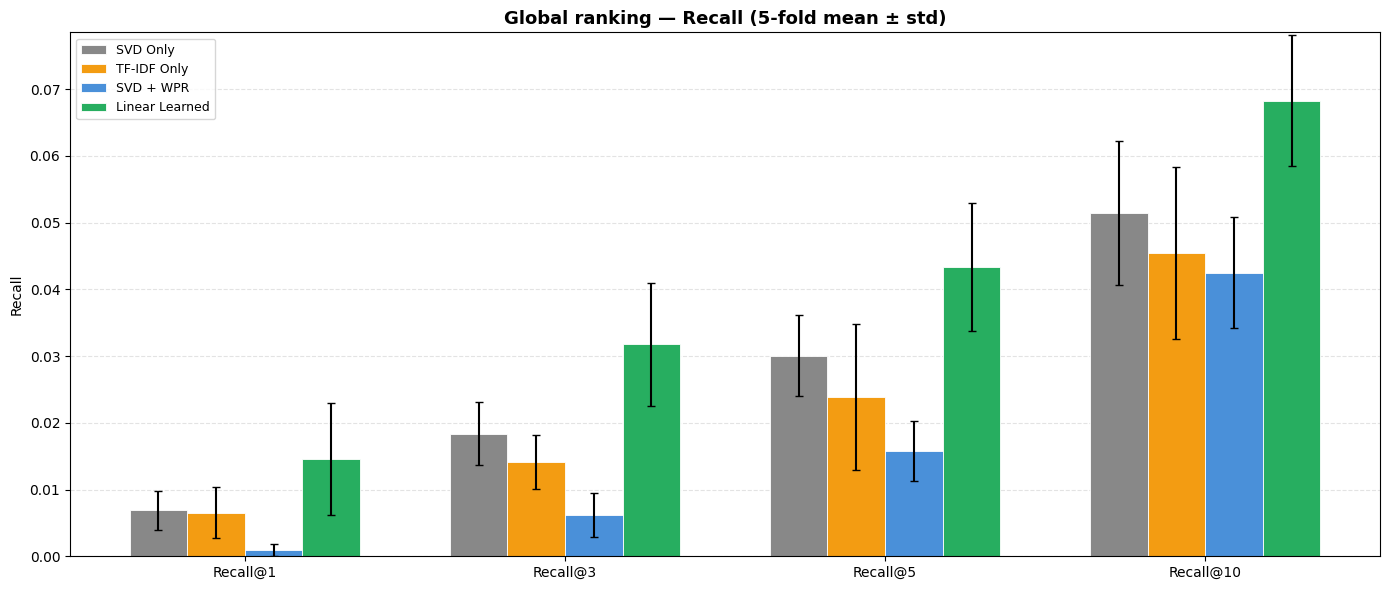

MAP — Global (mean / std trên 5 fold)


,SVD Only,TF-IDF Only,SVD + WPR,Linear Learned
k,,,,
1,0.0069,0.0065,0.0009,0.0145
3,0.0125,0.0096,0.0030,0.0230
5,0.0162,0.0119,0.0052,0.0263
10,0.0208,0.0155,0.0094,0.0315


,SVD Only,TF-IDF Only,SVD + WPR,Linear Learned
k,,,,
1,0.0030,0.0038,0.0009,0.0084
3,0.0037,0.0029,0.0013,0.0092
5,0.0037,0.0039,0.0011,0.0092
10,0.0046,0.0040,0.0017,0.0082


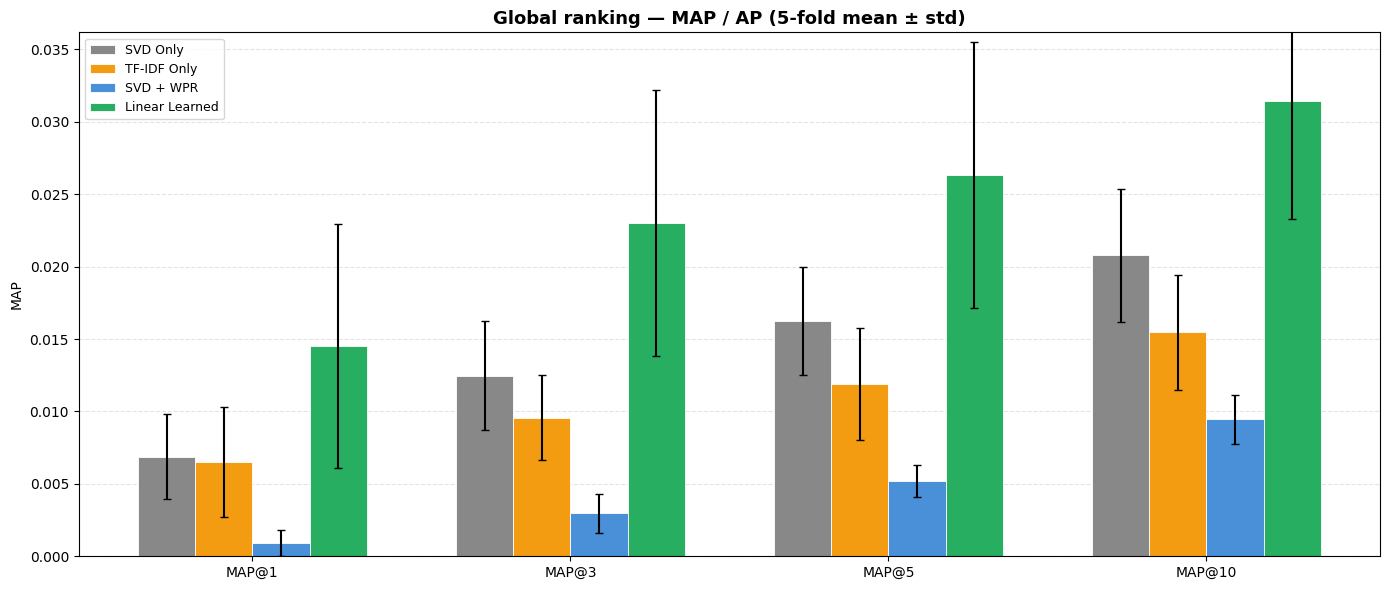

In [7]:
n_models = len(MODEL_KEYS)

# Bảng + biểu đồ: giá trị raw như mathai-lastversion (1).ipynb (không scale 10–100)
for short, longtitle in GLOBAL_METRIC_SPEC:
    mean_rows = []
    std_rows = []
    for k_div in K_DIV_GLOBAL_DIV:
        rm = {"k": k_div}
        rs = {"k": k_div}
        for mk, label in zip(MODEL_KEYS, MODEL_LABELS):
            c = f"{short}@{k_div} {mk}"
            rm[label] = gbl_mean.get(c, np.nan)
            rs[label] = gbl_std.get(c, np.nan)
        mean_rows.append(rm)
        std_rows.append(rs)
    print(longtitle)
    display(pd.DataFrame(mean_rows).set_index("k").round(4))
    display(pd.DataFrame(std_rows).set_index("k").round(4))

for k_div in K_DIV_GLOBAL_DIV:
    fig_g, axes_g = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
    for ax, (short, longtitle) in zip(axes_g, GLOBAL_METRIC_SPEC):
        vals = []
        errs = []
        for mk in MODEL_KEYS:
            c = f"{short}@{k_div} {mk}"
            vals.append(gbl_mean.get(c, 0.0))
            errs.append(gbl_std.get(c, 0.0))
        ax.bar(
            MODEL_LABELS,
            vals,
            yerr=errs,
            capsize=3,
            color=MODEL_COLORS,
            edgecolor="white",
            linewidth=0.8,
        )
        finite_hi = [v + e for v, e in zip(vals, errs) if np.isfinite(v) and np.isfinite(e)]
        ymax = max(finite_hi) if finite_hi else 1e-6
        finite_lo = [v - e for v, e in zip(vals, errs) if np.isfinite(v) and np.isfinite(e)]
        ymin = min(finite_lo) if finite_lo else 0.0
        ymin = min(ymin, 0.0)
        if np.isnan(ymin) or np.isnan(ymax):
            ax.set_ylim(0, 1)
        else:
            pad = 0.05 * (ymax - ymin + 1e-9)
            if errs and not np.all(np.isnan(errs)):
                err_max = float(np.nanmax(errs))
            else:
                err_max = 0.0
            ax.set_ylim(ymin - pad, ymax + pad + err_max * 0.15)
        ax.set_title(f"{short} @ top-{k_div}", fontsize=11, fontweight="bold")
        ax.set_ylabel(GLOBAL_PLOT_YLABEL.get(short, short))
        ax.tick_params(axis="x", rotation=22)
        ax.grid(axis="y", linestyle="--", alpha=0.35)
        ax.set_axisbelow(True)
        for i, v in enumerate(vals):
            if not np.isfinite(v):
                continue
            ei = errs[i] if i < len(errs) else 0.0
            ax.text(
                i,
                v + ei + 0.02 * max(ymax - ymin, 1e-9),
                f"{v:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="bold",
            )
    fig_g.suptitle(
        f"Global ranking — Coverage / Novelty / ILD @ top-{k_div} (5-fold mean ± std, lastversion-style)",
        fontsize=13,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

for mk, label in zip(MODEL_KEYS, MODEL_LABELS):
    parts = []
    for k_div in K_DIV_GLOBAL_DIV:
        bits = []
        for short, _ in GLOBAL_METRIC_SPEC:
            c = f"{short}@{k_div} {mk}"
            bits.append(f"{short}={gbl_mean.get(c, float('nan')):.3f}")
        parts.append(f"@{k_div}: " + ", ".join(bits))
    print(f"{label:35s} | " + " | ".join(parts))


# --- Global: NDCG, Recall, MAP (K_NDCG_COMPARE) — bảng mean/std + biểu đồ cột nhóm ---


def global_accuracy_tables_and_chart(metric_prefix, chart_title):
    mean_rows, std_rows = [], []
    for k_val in K_NDCG_COMPARE:
        rm, rs = {"k": k_val}, {"k": k_val}
        for mk, label in zip(MODEL_KEYS, MODEL_LABELS):
            c = f"{metric_prefix}@{k_val} {mk}"
            rm[label] = gbl_mean.get(c, np.nan)
            rs[label] = gbl_std.get(c, np.nan)
        mean_rows.append(rm)
        std_rows.append(rs)
    print(f"{metric_prefix} — Global (mean / std trên 5 fold)")
    display(pd.DataFrame(mean_rows).set_index("k").round(4))
    display(pd.DataFrame(std_rows).set_index("k").round(4))

    fig_a, ax_a = plt.subplots(figsize=(14, 6))
    x_a = np.arange(len(K_NDCG_COMPARE))
    w_a = 0.18
    off_a = [(i - (n_models - 1) / 2) * w_a for i in range(n_models)]
    all_vals = []
    for idx_m, (mk, label, color) in enumerate(zip(MODEL_KEYS, MODEL_LABELS, MODEL_COLORS)):
        vals = [gbl_mean.get(f"{metric_prefix}@{k} {mk}", 0) for k in K_NDCG_COMPARE]
        errs = [gbl_std.get(f"{metric_prefix}@{k} {mk}", 0) for k in K_NDCG_COMPARE]
        all_vals += vals
        ax_a.bar(
            x_a + off_a[idx_m],
            vals,
            w_a,
            yerr=errs,
            capsize=3,
            label=label,
            color=color,
            edgecolor="white",
            linewidth=0.6,
        )
    ax_a.set_xticks(x_a)
    ax_a.set_xticklabels([f"{metric_prefix}@{k}" for k in K_NDCG_COMPARE])
    ax_a.set_ylabel(metric_prefix)
    ax_a.set_title(chart_title, fontsize=13, fontweight="bold")
    ymax_a = max([v for v in all_vals if np.isfinite(v)] + [0.02])
    ax_a.set_ylim(0, min(ymax_a * 1.15, 1.05))
    ax_a.legend(loc="upper left", frameon=True, fontsize=9)
    ax_a.grid(axis="y", linestyle="--", alpha=0.35)
    ax_a.set_axisbelow(True)
    plt.tight_layout()
    plt.show()


global_accuracy_tables_and_chart("NDCG", "Global ranking — NDCG (5-fold mean ± std)")
global_accuracy_tables_and_chart("Recall", "Global ranking — Recall (5-fold mean ± std)")
global_accuracy_tables_and_chart("MAP", "Global ranking — MAP / AP (5-fold mean ± std)")


In [8]:
def svd_rank_restricted(svd_model, raw_uid, candidate_mids, seen_movies):
    scored = []
    for m in candidate_mids:
        if m in seen_movies:
            continue
        est = svd_model.predict(raw_uid, m).est
        scored.append((m, est))
    scored.sort(key=lambda x: -x[1])
    return [m for m, _ in scored], {m: s for m, s in scored}


def tfidf_rank_restricted(raw_uid, candidate_mids, seen_movies, train_df):
    prof = user_profile_vector(raw_uid, train_df)
    if prof is None:
        return list(candidate_mids)

    scored = []
    for m in candidate_mids:
        if m in seen_movies:
            continue
        r = mid_to_row.get(m)
        if r is None:
            scored.append((m, 0.0))
            continue
        mv = np.asarray(X_movies[r].toarray()).ravel()
        nm = np.linalg.norm(mv)
        if nm < 1e-12:
            scored.append((m, 0.0))
        else:
            scored.append((m, float(np.dot(prof, mv / nm))))

    scored.sort(key=lambda x: -x[1])
    return [m for m, _ in scored]


def svd_wpr_rank_restricted(raw_uid, candidates, wpr_fn):
    scored = [(m, wpr_fn(raw_uid, m)) for m in candidates]
    scored.sort(key=lambda x: -x[1])
    return [m for m, _ in scored]


In [9]:
def run_one_fold_restricted(fold_id, train_df, test_df):
    reader = Reader(rating_scale=(1, 5))
    train_surprise = Dataset.load_from_df(train_df[["userId", "movieId", "rating"]], reader)
    trainset = train_surprise.build_full_trainset()
    svd = SVD(n_factors=50, n_epochs=25, lr_all=0.005, reg_all=0.02, random_state=RANDOM_STATE)
    svd.fit(trainset)

    rdict = ratings_dict(train_df)
    gmean = float(train_df["rating"].mean())
    users_sorted = sorted(rdict.keys())
    sim_mat, uid_to_idx, mean_u = precompute_user_sim(rdict, users_sorted, MIN_COMMON)

    pop_counts = train_df["movieId"].value_counts()
    total_ratings = int(len(train_df))
    num_items_catalog = int(len(all_movie_ids))

    def wpr_score(u, movie_id):
        if u not in uid_to_idx:
            return gmean
        sim_row = sim_mat[uid_to_idx[u]]
        return wpr_predict(u, movie_id, rdict, mean_u, sim_row, uid_to_idx, users_sorted, K=K_WPR, gmean=gmean)

    blend_model = fit_linear_blend_model(train_df, svd, wpr_score)

    coverage_sets = {mk: {kk: set() for kk in K_NDCG_COMPARE} for mk in MODEL_KEYS}
    novelty_vals = {mk: {kk: [] for kk in K_NDCG_COMPARE} for mk in MODEL_KEYS}
    ild_vals = {mk: {kk: [] for kk in K_NDCG_COMPARE} for mk in MODEL_KEYS}
    restricted_universe = set()

    cand_users = test_df["userId"].unique()
    n_pick = min(EVAL_USERS, len(cand_users))
    rng = np.random.RandomState(RANDOM_STATE + fold_id)
    eval_users = rng.choice(cand_users, size=n_pick, replace=False)

    rows = []
    for u in eval_users:
        seen = set(train_df.loc[train_df["userId"] == u, "movieId"].astype(int))
        relevant = set(test_df.loc[(test_df["userId"] == u) & (test_df["rating"] >= 4.0), "movieId"].astype(int))
        relevant = {int(x) for x in relevant if int(x) not in seen}
        if len(relevant) < 1:
            continue

        tu = test_df.loc[test_df["userId"] == u, ["movieId", "rating"]]
        test_rating_by_movie = dict(zip(tu["movieId"].astype(int), tu["rating"].astype(float)))

        restricted_mids = list(test_rating_by_movie.keys())
        restricted_universe.update(int(m) for m in restricted_mids)

        rank_svd, svd_scores = svd_rank_restricted(svd, int(u), restricted_mids, seen)
        rank_tfidf = tfidf_rank_restricted(int(u), restricted_mids, seen, train_df)
        rank_svd_wpr = svd_wpr_rank_restricted(int(u), rank_svd, wpr_score)

        candidates_linear = list(dict.fromkeys(rank_svd[:TOP_SVD] + rank_tfidf[:TOP_SVD]))
        for m in candidates_linear:
            if m not in svd_scores:
                svd_scores[m] = float(svd.predict(int(u), m).est)

        rank_linear = learned_linear_rank_svd_tfidf_wpr(
            int(u), candidates_linear, svd_scores, train_df, wpr_score, blend_model
        )

        all_ranks = {
            "SVD": rank_svd,
            "TFIDF": rank_tfidf,
            "SVD_WPR": rank_svd_wpr,
            "LinearLearned": rank_linear,
        }

        row = {"fold": fold_id, "userId": int(u), "|rel|": len(relevant)}
        for kk in K_NDCG_COMPARE:
            for mk in MODEL_KEYS:
                rank = all_ranks[mk]
                topk = rank[:kk]
                coverage_sets[mk][kk].update(int(m) for m in topk)
                nov = novelty_at_k(rank, kk, pop_counts, total_ratings, num_items_catalog)
                if not np.isnan(nov):
                    novelty_vals[mk][kk].append(float(nov))
                div = diversity_at_k(rank, kk)
                if not np.isnan(div):
                    ild_vals[mk][kk].append(float(div))
                row[f"NDCG@{kk} {mk}"] = ndcg_u_at_top_n(rank, test_rating_by_movie, kk)
                row[f"Recall@{kk} {mk}"] = recall_at_k(rank, relevant, kk)
                row[f"MAP@{kk} {mk}"] = map_u_at_top_n(rank, relevant, kk)
                row[f"Novelty@{kk} {mk}"] = nov
                row[f"ILD@{kk} {mk}"] = div
        rows.append(row)

    denom_cov = max(1, len(restricted_universe))
    fold_extra = {}
    for mk in MODEL_KEYS:
        for kk in K_NDCG_COMPARE:
            fold_extra[f"Coverage@{kk} {mk}"] = len(coverage_sets[mk][kk]) / denom_cov
            fold_extra[f"Novelty@{kk} {mk}"] = (
                float(np.mean(novelty_vals[mk][kk])) if novelty_vals[mk][kk] else np.nan
            )
            fold_extra[f"ILD@{kk} {mk}"] = float(np.mean(ild_vals[mk][kk])) if ild_vals[mk][kk] else np.nan

    return pd.DataFrame(rows), fold_extra


kf3 = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
idx3 = np.arange(len(ratings))

restricted_fold_metrics = []
restricted_fold_summaries = []

for fold_id, (train_idx, test_idx) in enumerate(kf3.split(idx3)):
    train_k = ratings.iloc[train_idx].reset_index(drop=True)
    test_k = ratings.iloc[test_idx].reset_index(drop=True)
    print(f"--- Fold {fold_id + 1}/{N_FOLDS} | train {len(train_k)} | test {len(test_k)} ---")
    mdf, fold_extra = run_one_fold_restricted(fold_id + 1, train_k, test_k)
    restricted_fold_metrics.append(mdf)

    acc_cols = [
        c
        for c in mdf.columns
        if c not in ("fold", "userId", "|rel|")
        and c.startswith(("NDCG@", "Recall@", "MAP@"))
    ]
    means_acc = mdf[acc_cols].mean(numeric_only=True) if not mdf.empty and acc_cols else pd.Series()
    restricted_fold_summaries.append({"fold": fold_id + 1, **means_acc.to_dict(), **fold_extra})

restricted_per_fold_df = pd.DataFrame(restricted_fold_summaries)
restricted_full = pd.concat(restricted_fold_metrics, ignore_index=True)

restricted_agg_cols = [c for c in restricted_per_fold_df.columns if c != "fold"]
rst_mean = restricted_per_fold_df[restricted_agg_cols].mean()
rst_std = restricted_per_fold_df[restricted_agg_cols].std()
rst_summary = pd.DataFrame({"mean": rst_mean, "std": rst_std})
display(rst_summary)

if os.path.isdir(out_dir):
    restricted_per_fold_df.to_csv(os.path.join(out_dir, "restricted_4models_fold_means.csv"), index=False)
    rst_summary.to_csv(os.path.join(out_dir, "restricted_4models_summary.csv"))
    restricted_full.to_csv(os.path.join(out_dir, "restricted_4models_all_users.csv"), index=False)
    print("Saved CSV", out_dir)


--- Fold 1/5 | train 80000 | test 20000 ---
--- Fold 2/5 | train 80000 | test 20000 ---
--- Fold 3/5 | train 80000 | test 20000 ---
--- Fold 4/5 | train 80000 | test 20000 ---
--- Fold 5/5 | train 80000 | test 20000 ---


,mean,std
NDCG@1 SVD,0.740138,0.033983
Recall@1 SVD,0.147219,0.012413
MAP@1 SVD,0.147219,0.012413
NDCG@1 TFIDF,0.507340,0.010107
Recall@1 TFIDF,0.100866,0.009481
...,...,...
Novelty@5 LinearLearned,9.089300,0.053222
ILD@5 LinearLearned,0.848937,0.001081
Coverage@10 LinearLearned,0.457470,0.046599
Novelty@10 LinearLearned,9.235746,0.037363


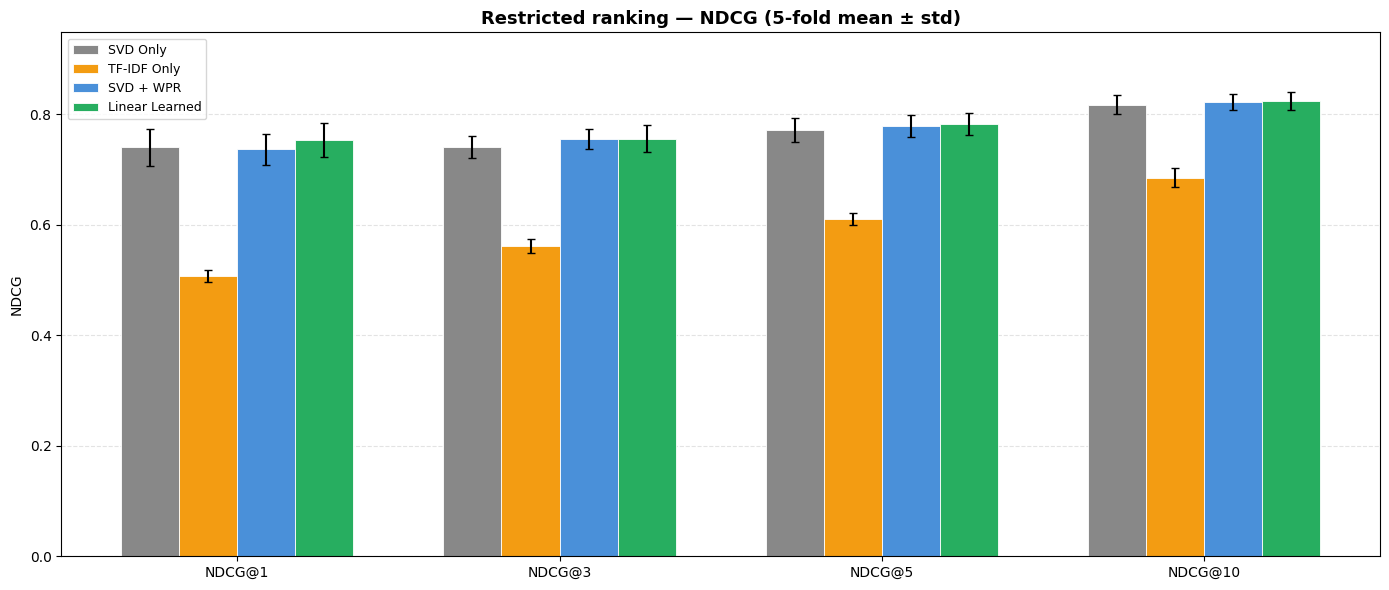

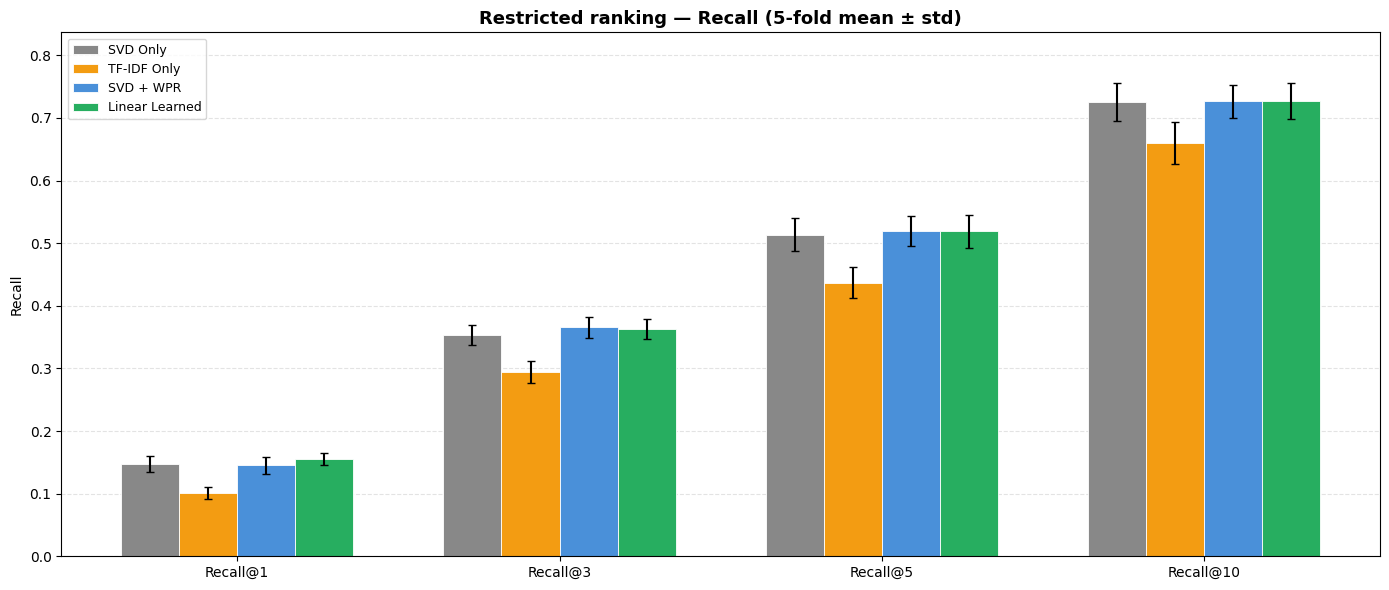

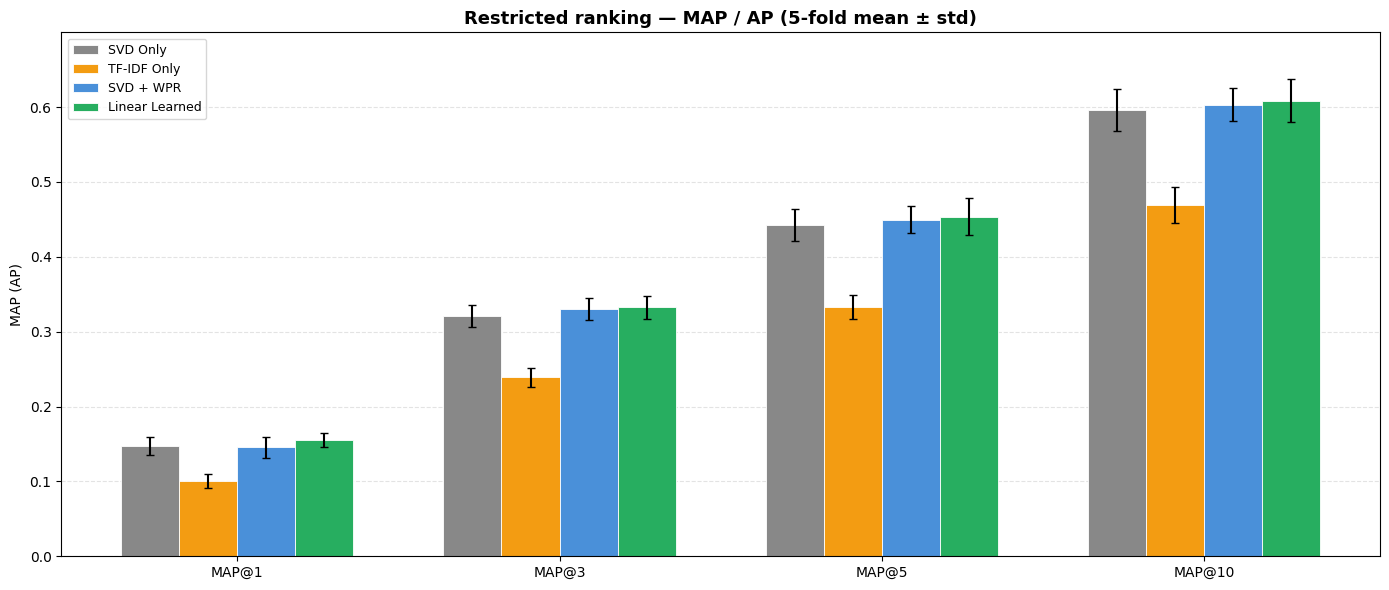

,SVD Only (mean),SVD Only (std),TF-IDF Only (mean),TF-IDF Only (std),SVD + WPR (mean),SVD + WPR (std),Linear Learned (mean),Linear Learned (std)
@1,0.740138,0.033983,0.507340,0.010107,0.736576,0.027662,0.753974,0.030763
@3,0.740696,0.019887,0.561261,0.012261,0.754762,0.017972,0.756178,0.023844
@5,0.771543,0.021363,0.610664,0.011192,0.779131,0.019559,0.781936,0.020096
@10,0.817675,0.016936,0.685171,0.017210,0.822662,0.014277,0.824690,0.016226


,SVD Only (mean),SVD Only (std),TF-IDF Only (mean),TF-IDF Only (std),SVD + WPR (mean),SVD + WPR (std),Linear Learned (mean),Linear Learned (std)
@1,0.147219,0.012413,0.100866,0.009481,0.145334,0.013491,0.155060,0.009103
@3,0.353206,0.016502,0.294262,0.016963,0.365495,0.016499,0.362957,0.015238
@5,0.513376,0.026631,0.436874,0.025040,0.519021,0.023942,0.519187,0.026582
@10,0.725401,0.030014,0.659650,0.033198,0.726739,0.026157,0.727585,0.028760


,SVD Only (mean),SVD Only (std),TF-IDF Only (mean),TF-IDF Only (std),SVD + WPR (mean),SVD + WPR (std),Linear Learned (mean),Linear Learned (std)
@1,0.147219,0.012413,0.100866,0.009481,0.145334,0.013491,0.155060,0.009103
@3,0.321056,0.014894,0.239081,0.012679,0.330709,0.014819,0.332725,0.015184
@5,0.442743,0.021334,0.333149,0.016188,0.449355,0.017983,0.453613,0.024498
@10,0.596517,0.028159,0.469067,0.024178,0.603351,0.022375,0.608519,0.028750


Coverage — |∪ top-k| / |test items trong fold| (restricted pool)


,SVD Only,TF-IDF Only,SVD + WPR,Linear Learned
k,,,,
1,0.0741,0.0926,0.0715,0.0682
3,0.1942,0.2242,0.1870,0.1849
5,0.2929,0.3283,0.2855,0.2801
10,0.4649,0.5149,0.4575,0.4575


...

,SVD Only,TF-IDF Only,SVD + WPR,Linear Learned
k,,,,
1,8.7209,9.4413,9.0059,8.7735
3,8.9324,9.4937,9.0550,8.9676
5,9.0585,9.4752,9.1370,9.0893
10,9.2466,9.4848,9.2568,9.2357


,SVD Only,TF-IDF Only,SVD + WPR,Linear Learned
k,,,,
1,0.0923,0.0323,0.0963,0.1352
3,0.0661,0.1003,0.0750,0.0754
5,0.0656,0.0883,0.0513,0.0532
10,0.0440,0.0584,0.0445,0.0374


ILD — mean (1 - cos TF-IDF) trong top-k


,SVD Only,TF-IDF Only,SVD + WPR,Linear Learned
k,,,,
1,NaN,NaN,NaN,NaN
3,0.8757,0.6084,0.8730,0.8367
5,0.8723,0.6971,0.8696,0.8489
10,0.8720,0.7809,0.8716,0.8611


,SVD Only,TF-IDF Only,SVD + WPR,Linear Learned
k,,,,
1,NaN,NaN,NaN,NaN
3,0.0048,0.0180,0.0046,0.0068
5,0.0024,0.0173,0.0037,0.0011
10,0.0060,0.0128,0.0053,0.0051


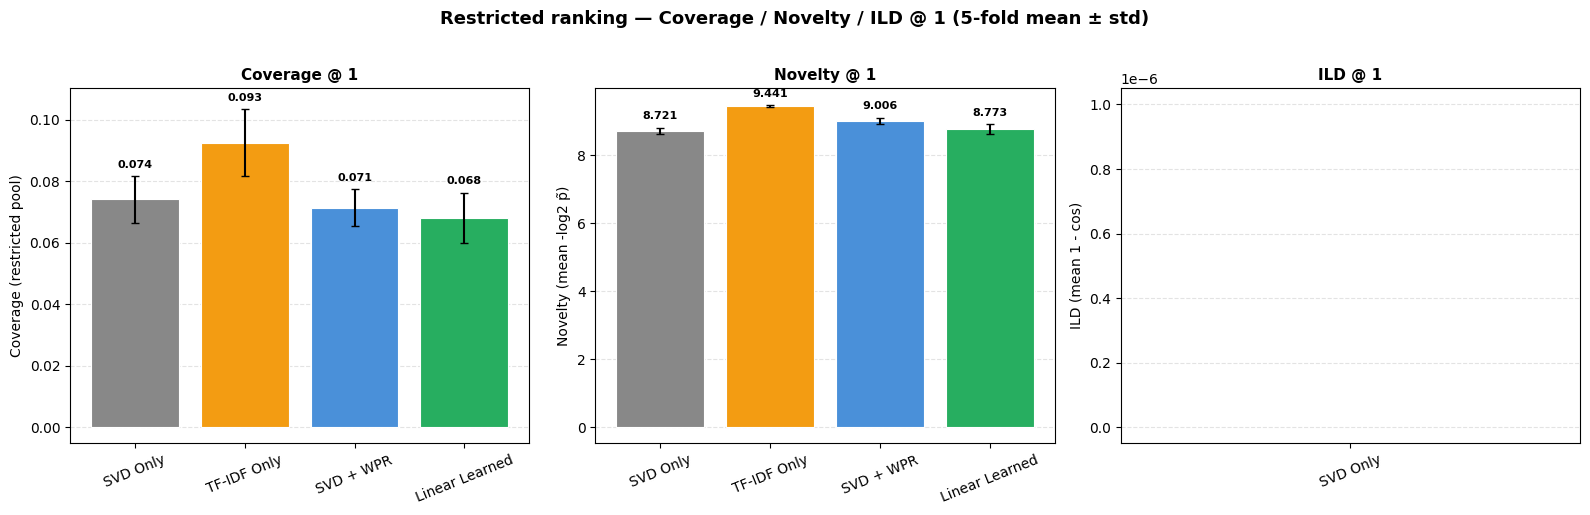

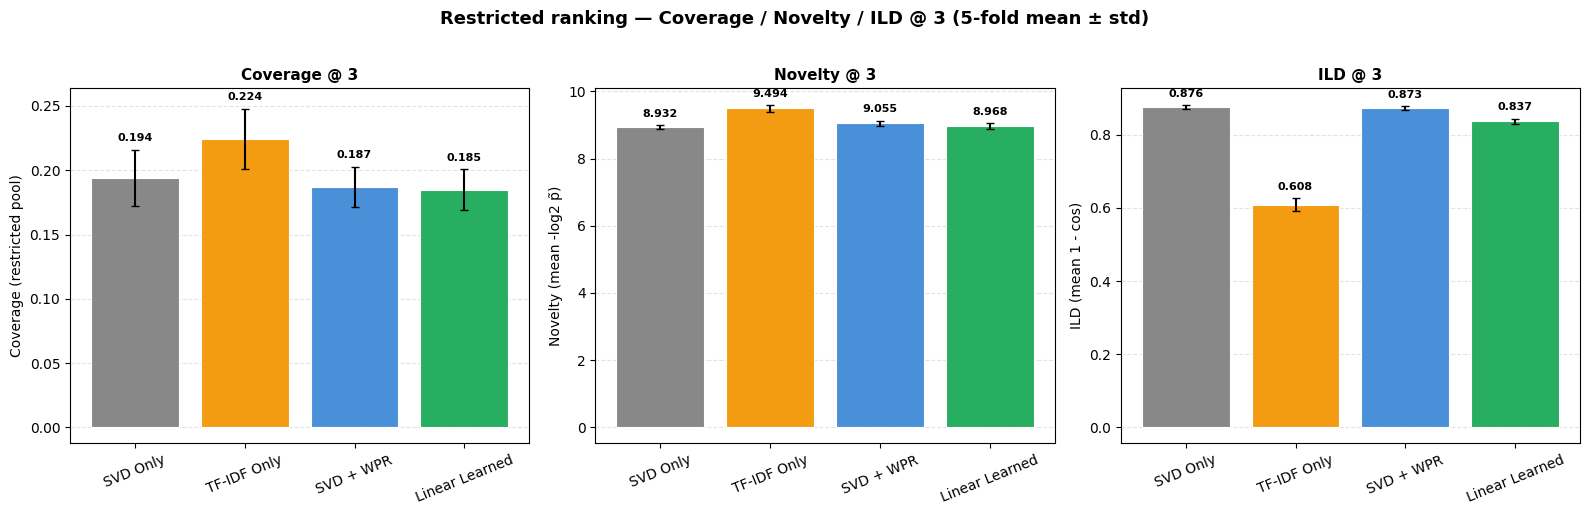

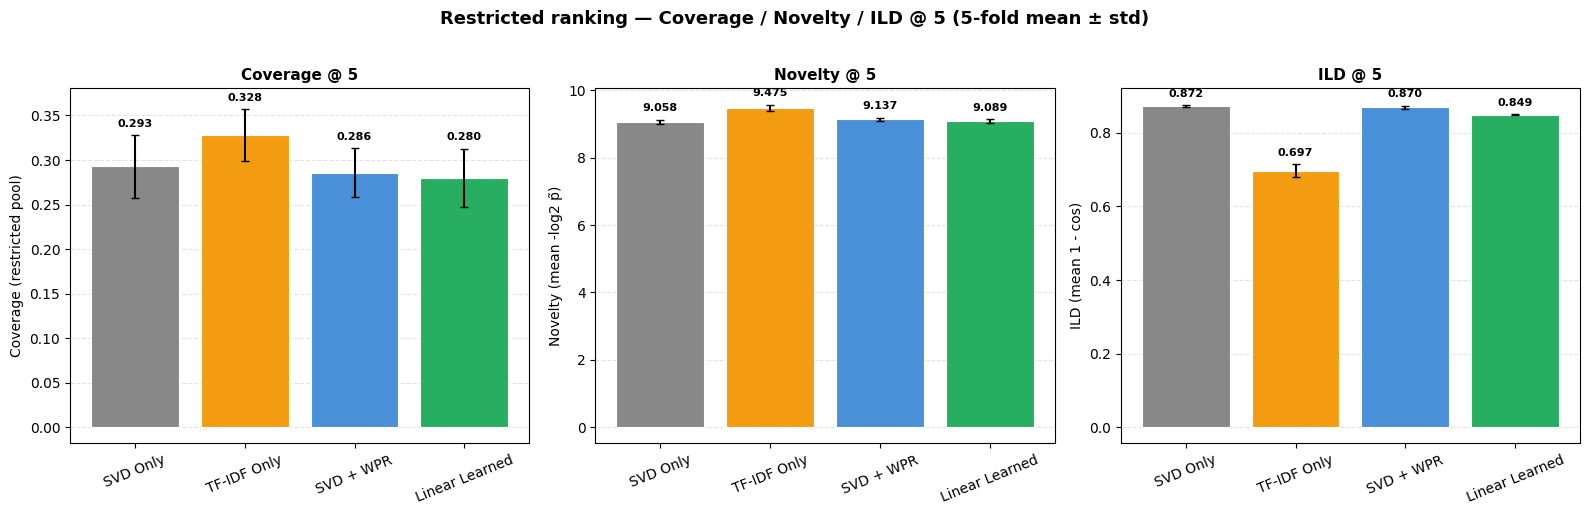

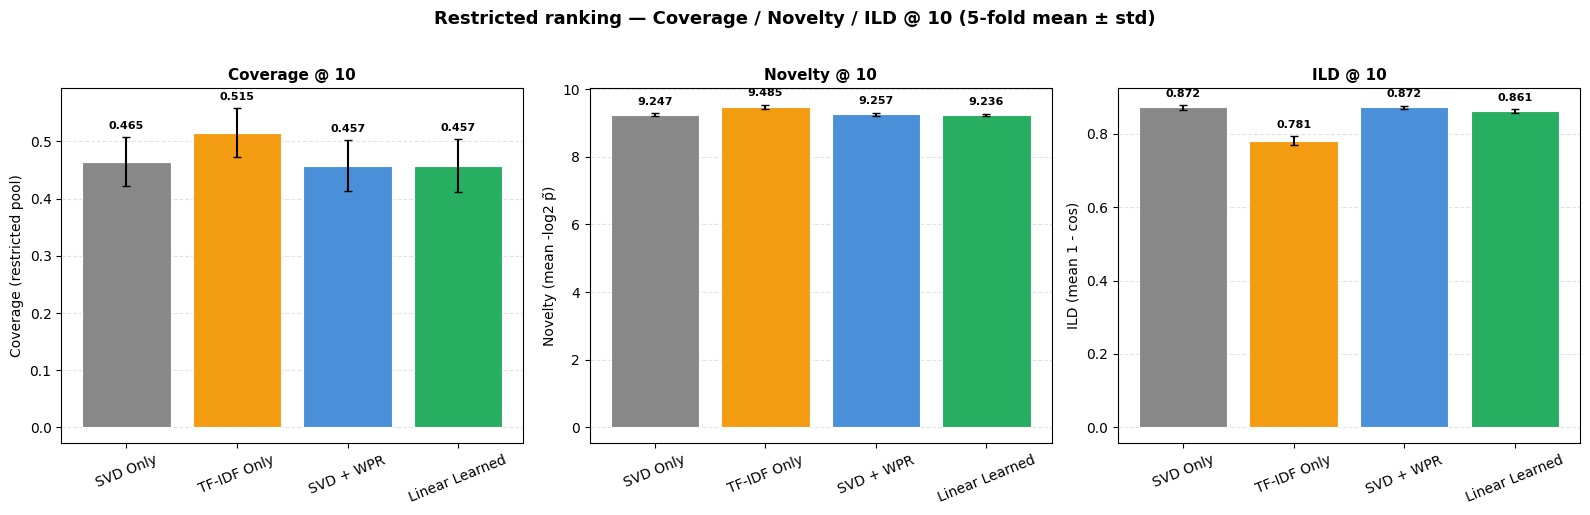

SVD Only                            | NDCG@10 = 0.817675 | Recall@10 = 0.725401 | MAP@10 = 0.596517
TF-IDF Only                         | NDCG@10 = 0.685171 | Recall@10 = 0.659650 | MAP@10 = 0.469067
SVD + WPR                           | NDCG@10 = 0.822662 | Recall@10 = 0.726739 | MAP@10 = 0.603351
Linear Learned                      | NDCG@10 = 0.824690 | Recall@10 = 0.727585 | MAP@10 = 0.608519
Best by Restricted NDCG@10: Linear Learned


In [10]:
fig_rst_nd, ax_rst_nd = plt.subplots(figsize=(14, 6))
x_nd = np.arange(len(K_NDCG_COMPARE))
w = 0.18
offsets_nd = [(i - (n_models - 1) / 2) * w for i in range(n_models)]

for idx_m, (mk, label, color) in enumerate(zip(MODEL_KEYS, MODEL_LABELS, MODEL_COLORS)):
    vals = [rst_mean.get(f"NDCG@{k} {mk}", 0) for k in K_NDCG_COMPARE]
    errs = [rst_std.get(f"NDCG@{k} {mk}", 0) for k in K_NDCG_COMPARE]
    ax_rst_nd.bar(
        x_nd + offsets_nd[idx_m],
        vals,
        w,
        yerr=errs,
        capsize=3,
        label=label,
        color=color,
        edgecolor="white",
        linewidth=0.6,
    )
ax_rst_nd.set_xticks(x_nd)
ax_rst_nd.set_xticklabels([f"NDCG@{k}" for k in K_NDCG_COMPARE])
ax_rst_nd.set_ylabel("NDCG")
ax_rst_nd.set_title(
    "Restricted ranking — NDCG (5-fold mean ± std)",
    fontsize=13,
    fontweight="bold",
)
all_rst_nd = []
for mk in MODEL_KEYS:
    all_rst_nd += [rst_mean.get(f"NDCG@{k} {mk}", 0) for k in K_NDCG_COMPARE]
ymax_rst_nd = max([v for v in all_rst_nd if np.isfinite(v)] + [0.02])
ax_rst_nd.set_ylim(0, min(ymax_rst_nd * 1.15, 1.0))
ax_rst_nd.legend(loc="upper left", frameon=True, fontsize=9)
ax_rst_nd.grid(axis="y", linestyle="--", alpha=0.35)
ax_rst_nd.set_axisbelow(True)
plt.tight_layout()
plt.show()

fig_rst_rc, ax_rst_rc = plt.subplots(figsize=(14, 6))
for idx_m, (mk, label, color) in enumerate(zip(MODEL_KEYS, MODEL_LABELS, MODEL_COLORS)):
    vals = [rst_mean.get(f"Recall@{k} {mk}", 0) for k in K_NDCG_COMPARE]
    errs = [rst_std.get(f"Recall@{k} {mk}", 0) for k in K_NDCG_COMPARE]
    ax_rst_rc.bar(
        x_nd + offsets_nd[idx_m],
        vals,
        w,
        yerr=errs,
        capsize=3,
        label=label,
        color=color,
        edgecolor="white",
        linewidth=0.6,
    )
ax_rst_rc.set_xticks(x_nd)
ax_rst_rc.set_xticklabels([f"Recall@{k}" for k in K_NDCG_COMPARE])
ax_rst_rc.set_ylabel("Recall")
ax_rst_rc.set_title(
    "Restricted ranking — Recall (5-fold mean ± std)",
    fontsize=13,
    fontweight="bold",
)
all_rst_rc = []
for mk in MODEL_KEYS:
    all_rst_rc += [rst_mean.get(f"Recall@{k} {mk}", 0) for k in K_NDCG_COMPARE]
ymax_rst_rc = max([v for v in all_rst_rc if np.isfinite(v)] + [0.02])
ax_rst_rc.set_ylim(0, min(ymax_rst_rc * 1.15, 1.0))
ax_rst_rc.legend(loc="upper left", frameon=True, fontsize=9)
ax_rst_rc.grid(axis="y", linestyle="--", alpha=0.35)
ax_rst_rc.set_axisbelow(True)
plt.tight_layout()
plt.show()

fig_rst_map, ax_rst_map = plt.subplots(figsize=(14, 6))
for idx_m, (mk, label, color) in enumerate(zip(MODEL_KEYS, MODEL_LABELS, MODEL_COLORS)):
    vals = [rst_mean.get(f"MAP@{k} {mk}", 0) for k in K_NDCG_COMPARE]
    errs = [rst_std.get(f"MAP@{k} {mk}", 0) for k in K_NDCG_COMPARE]
    ax_rst_map.bar(
        x_nd + offsets_nd[idx_m],
        vals,
        w,
        yerr=errs,
        capsize=3,
        label=label,
        color=color,
        edgecolor="white",
        linewidth=0.6,
    )
ax_rst_map.set_xticks(x_nd)
ax_rst_map.set_xticklabels([f"MAP@{k}" for k in K_NDCG_COMPARE])
ax_rst_map.set_ylabel("MAP (AP)")
ax_rst_map.set_title(
    "Restricted ranking — MAP / AP (5-fold mean ± std)",
    fontsize=13,
    fontweight="bold",
)
all_rst_map = []
for mk in MODEL_KEYS:
    all_rst_map += [rst_mean.get(f"MAP@{k} {mk}", 0) for k in K_NDCG_COMPARE]
ymax_rst_map = max([v for v in all_rst_map if np.isfinite(v)] + [0.02])
ax_rst_map.set_ylim(0, min(ymax_rst_map * 1.15, 1.0))
ax_rst_map.legend(loc="upper left", frameon=True, fontsize=9)
ax_rst_map.grid(axis="y", linestyle="--", alpha=0.35)
ax_rst_map.set_axisbelow(True)
plt.tight_layout()
plt.show()

ndcg_rst_data = {}
for mk, label in zip(MODEL_KEYS, MODEL_LABELS):
    ndcg_rst_data[f"{label} (mean)"] = [rst_mean.get(f"NDCG@{k} {mk}", np.nan) for k in K_NDCG_COMPARE]
    ndcg_rst_data[f"{label} (std)"] = [rst_std.get(f"NDCG@{k} {mk}", np.nan) for k in K_NDCG_COMPARE]
ndcg_rst_table = pd.DataFrame(ndcg_rst_data, index=[f"@{k}" for k in K_NDCG_COMPARE])
display(ndcg_rst_table)

recall_rst_data = {}
for mk, label in zip(MODEL_KEYS, MODEL_LABELS):
    recall_rst_data[f"{label} (mean)"] = [rst_mean.get(f"Recall@{k} {mk}", np.nan) for k in K_NDCG_COMPARE]
    recall_rst_data[f"{label} (std)"] = [rst_std.get(f"Recall@{k} {mk}", np.nan) for k in K_NDCG_COMPARE]
recall_rst_table = pd.DataFrame(recall_rst_data, index=[f"@{k}" for k in K_NDCG_COMPARE])
display(recall_rst_table)

map_rst_data = {}
for mk, label in zip(MODEL_KEYS, MODEL_LABELS):
    map_rst_data[f"{label} (mean)"] = [rst_mean.get(f"MAP@{k} {mk}", np.nan) for k in K_NDCG_COMPARE]
    map_rst_data[f"{label} (std)"] = [rst_std.get(f"MAP@{k} {mk}", np.nan) for k in K_NDCG_COMPARE]
map_rst_table = pd.DataFrame(map_rst_data, index=[f"@{k}" for k in K_NDCG_COMPARE])
display(map_rst_table)

RESTRICT_DIV_SPEC = [
    ("Coverage", "Coverage — |∪ top-k| / |test items trong fold| (restricted pool)"),
    ("Novelty", "Novelty — -log2(p) Laplace (lastversion)"),
    ("ILD", "ILD — mean (1 - cos TF-IDF) trong top-k"),
]

RESTRICT_DIV_YLABEL = {
    "Coverage": "Coverage (restricted pool)",
    "Novelty": "Novelty (mean -log2 p̃)",
    "ILD": "ILD (mean 1 - cos)",
}

for short, longtitle in RESTRICT_DIV_SPEC:
    mean_rows = []
    std_rows = []
    for k_val in K_NDCG_COMPARE:
        rm = {"k": k_val}
        rs = {"k": k_val}
        for mk, label in zip(MODEL_KEYS, MODEL_LABELS):
            c = f"{short}@{k_val} {mk}"
            rm[label] = rst_mean.get(c, np.nan)
            rs[label] = rst_std.get(c, np.nan)
        mean_rows.append(rm)
        std_rows.append(rs)
    print(longtitle)
    display(pd.DataFrame(mean_rows).set_index("k").round(4))
    display(pd.DataFrame(std_rows).set_index("k").round(4))

for k_val in K_NDCG_COMPARE:
    fig_rdiv, axes_rdiv = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
    for ax, (short, longtitle) in zip(axes_rdiv, RESTRICT_DIV_SPEC):
        vals = []
        errs = []
        for mk in MODEL_KEYS:
            c = f"{short}@{k_val} {mk}"
            vals.append(rst_mean.get(c, 0.0))
            errs.append(rst_std.get(c, 0.0))
        ax.bar(
            MODEL_LABELS,
            vals,
            yerr=errs,
            capsize=3,
            color=MODEL_COLORS,
            edgecolor="white",
            linewidth=0.8,
        )
        finite_hi = [v + e for v, e in zip(vals, errs) if np.isfinite(v) and np.isfinite(e)]
        ymax = max(finite_hi) if finite_hi else 1e-6
        finite_lo = [v - e for v, e in zip(vals, errs) if np.isfinite(v) and np.isfinite(e)]
        ymin = min(finite_lo) if finite_lo else 0.0
        ymin = min(ymin, 0.0)
        if np.isnan(ymin) or np.isnan(ymax):
            ax.set_ylim(0, 1)
        else:
            pad = 0.05 * (ymax - ymin + 1e-9)
            if errs and not np.all(np.isnan(errs)):
                err_max = float(np.nanmax(errs))
            else:
                err_max = 0.0
            ax.set_ylim(ymin - pad, ymax + pad + err_max * 0.15)
        ax.set_title(f"{short} @ {k_val}", fontsize=11, fontweight="bold")
        ax.set_ylabel(RESTRICT_DIV_YLABEL.get(short, short))
        ax.tick_params(axis="x", rotation=22)
        ax.grid(axis="y", linestyle="--", alpha=0.35)
        ax.set_axisbelow(True)
        for i, v in enumerate(vals):
            if not np.isfinite(v):
                continue
            ei = errs[i] if i < len(errs) else 0.0
            ax.text(
                i,
                v + ei + 0.02 * max(ymax - ymin, 1e-9),
                f"{v:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="bold",
            )
    fig_rdiv.suptitle(
        f"Restricted ranking — Coverage / Novelty / ILD @ {k_val} (5-fold mean ± std)",
        fontsize=13,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

for mk, label in zip(MODEL_KEYS, MODEL_LABELS):
    ndcg10 = rst_mean.get(f"NDCG@10 {mk}", 0)
    recall10 = rst_mean.get(f"Recall@10 {mk}", 0)
    map10 = rst_mean.get(f"MAP@10 {mk}", 0)
    print(
        f"{label:35s} | NDCG@10 = {ndcg10:.6f} | Recall@10 = {recall10:.6f} | MAP@10 = {map10:.6f}"
    )

best_model_idx = max(range(len(MODEL_KEYS)), key=lambda i: rst_mean.get(f"NDCG@10 {MODEL_KEYS[i]}", 0))
print(f"Best by Restricted NDCG@10: {MODEL_LABELS[best_model_idx]}")


In [11]:
# --- BƯỚC HUẤN LUYỆN TOÀN BỘ HỆ THỐNG ---
print("Đang huấn luyện mô hình trên toàn bộ dữ liệu (vui lòng đợi)...")

# 1. Huấn luyện SVD (Surprise)
reader = Reader(rating_scale=(1, 5))
train_surprise = Dataset.load_from_df(ratings[["userId", "movieId", "rating"]], reader)
full_trainset = train_surprise.build_full_trainset()
svd = SVD(n_factors=50, n_epochs=25, lr_all=0.005, reg_all=0.02, random_state=RANDOM_STATE)
svd.fit(full_trainset)

# 2. Xây dựng rdict và tính toán User Similarity (WPR)
rdict = ratings_dict(ratings)
gmean = float(ratings["rating"].mean())
users_sorted = sorted(rdict.keys())
sim_mat, uid_to_idx, mean_u = precompute_user_sim(rdict, users_sorted, MIN_COMMON)

# 3. Tạo hàm wpr_score để huấn luyện Blend Model
def wpr_score_for_train(u, movie_id):
    if u not in uid_to_idx: return gmean
    sim_row = sim_mat[uid_to_idx[u]]
    return wpr_predict(u, movie_id, rdict, mean_u, sim_row, uid_to_idx, users_sorted, K=K_WPR, gmean=gmean)

# 4. Huấn luyện Blend Model (Mô hình Hybrid)
blend_model = fit_linear_blend_model(ratings, svd, wpr_score_for_train)

print("Huấn luyện thành công! Bây giờ bạn có thể chạy hàm đề xuất.")


Đang huấn luyện mô hình trên toàn bộ dữ liệu (vui lòng đợi)...
Huấn luyện thành công! Bây giờ bạn có thể chạy hàm đề xuất.


In [12]:
def get_hybrid_recommendations(target_user_id, top_n=10):
    seen_movies = set(ratings[ratings["userId"] == target_user_id]["movieId"].astype(int))
    
  
    def wpr_score_quick(u, movie_id):
        if u not in uid_to_idx:
            return ratings['rating'].mean()
        sim_row = sim_mat[uid_to_idx[u]]
        return wpr_predict(u, movie_id, rdict, mean_u, sim_row, uid_to_idx, users_list=None, K=K_WPR, gmean=ratings['rating'].mean())

    
    rank_svd, svd_scores_dict = svd_top_candidates(svd, target_user_id, seen_movies, topn=150)
    rank_tfidf = tfidf_top_candidates(target_user_id, seen_movies, ratings, topn=150)
    
    candidates = list(dict.fromkeys(rank_svd + rank_tfidf))
    
    for m in candidates:
        if m not in svd_scores_dict:
            svd_scores_dict[m] = float(svd.predict(target_user_id, m).est)

    
    recommended_ids = learned_linear_rank_svd_tfidf_wpr(
        target_user_id, candidates, svd_scores_dict, ratings, wpr_score_quick, blend_model
    )
    
    top_recommendations = recommended_ids[:top_n]
    result = items[items['movieId'].isin(top_recommendations)][['movieId', 'title', 'movie_text']]
    
    result['movieId'] = pd.Categorical(result['movieId'], categories=top_recommendations, ordered=True)
    result = result.sort_values('movieId')
    
    return result

USER_ID = 405 
top_k = 10

print(f"Đang tính toán đề xuất cho Người dùng {USER_ID}...")
recommendations = get_hybrid_recommendations(USER_ID, top_n=top_k)

print(f"\nTop {top_k} phim đề xuất (Hybrid Model):")
display(recommendations)


Đang tính toán đề xuất cho Người dùng 405...

Top 10 phim đề xuất (Hybrid Model):


,movieId,title,movie_text
495,496,It's a Wonderful Life (1946),It's a Wonderful Life (1946) Drama
143,144,Die Hard (1988),Die Hard (1988) Action Thriller
282,283,Emma (1996),Emma (1996) Drama Romance
530,531,Shine (1996),Shine (1996) Drama Romance
935,936,Brassed Off (1996),Brassed Off (1996) Comedy Drama Romance
482,483,Casablanca (1942),Casablanca (1942) Drama Romance War
13,14,"Postino, Il (1994)","Postino, Il (1994) Drama Romance"
1188,1189,Prefontaine (1997),Prefontaine (1997) Drama
1079,1080,Celestial Clockwork (1994),Celestial Clockwork (1994) Comedy
18,19,Antonia's Line (1995),Antonia's Line (1995) Drama


In [ ]:
def get_recommendations_all_models(target_user_id, top_n=10):
    # 0. Chuẩn bị dữ liệu phim đã xem
    seen_movies = set(ratings[ratings["userId"] == target_user_id]["movieId"].astype(int))
    
    # helper function để lấy thông tin phim từ list IDs
    def get_movie_info(movie_ids):
        res = items[items['movieId'].isin(movie_ids)][['movieId', 'title', 'movie_text']]
        res['movieId'] = pd.Categorical(res['movieId'], categories=movie_ids, ordered=True)
        return res.sort_values('movieId')

    # --- 1. SVD TRUYỀN THỐNG ---
    svd_ids, _ = svd_top_candidates(svd, target_user_id, seen_movies, topn=top_n)
    df_svd = get_movie_info(svd_ids)

    # --- 2. TF-IDF (CONTENT-BASED) ---
    tfidf_ids = tfidf_top_candidates(target_user_id, seen_movies, ratings, topn=top_n)
    df_tfidf = get_movie_info(tfidf_ids)

    # --- 3. HYBRID (LINEAR LEARNED) ---
    # Sử dụng lại hàm get_hybrid_recommendations đã tạo ở bước trước
    df_hybrid = get_hybrid_recommendations(target_user_id, top_n=top_n)

    return df_svd, df_tfidf, df_hybrid

# --- CHẠY VÀ HIỂN THỊ ---
USER_ID = 393  # Thử với một User ID bất kỳ
K = 10

svd_rec, tfidf_rec, hybrid_rec = get_recommendations_all_models(USER_ID, top_n=K)

print(f"=== SO SÁNH ĐỀ XUẤT CHO NGƯỜI DÙNG {USER_ID} ===")

print(f"\n1. SVD TRUYỀN THỐNG (Dựa trên hành vi cộng đồng):")
display(svd_rec[['title']])

print(f"\n2. TF-IDF ONLY (Dựa trên nội dung thể loại phim):")
display(tfidf_rec[['title']])

print(f"\n3. HYBRID MODEL (Kết hợp tối ưu các phương pháp):")
display(hybrid_rec[['title']])


=== SO SÁNH ĐỀ XUẤT CHO NGƯỜI DÙNG 405 ===

1. SVD TRUYỀN THỐNG (Dựa trên hành vi cộng đồng):


,title
495,It's a Wonderful Life (1946)
143,Die Hard (1988)
282,Emma (1996)
530,Shine (1996)
18,Antonia's Line (1995)
150,Willy Wonka and the Chocolate Factory (1971)
477,"Philadelphia Story, The (1940)"
13,"Postino, Il (1994)"
935,Brassed Off (1996)
901,"Big Lebowski, The (1998)"



2. TF-IDF ONLY (Dựa trên nội dung thể loại phim):


,title
1169,Spanking the Monkey (1994)
1185,"Inkwell, The (1994)"
1271,Talking About Sex (1994)
1332,Midnight Dancers (Sibak) (1994)
1625,Nobody Loves Me (Keiner liebt mich) (1994)
33,"Doom Generation, The (1995)"
92,Welcome to the Dollhouse (1995)
1459,Sleepover (1995)
1180,"Low Down Dirty Shame, A (1994)"
1490,Tough and Deadly (1995)



3. HYBRID MODEL (Kết hợp tối ưu các phương pháp):


,title
495,It's a Wonderful Life (1946)
143,Die Hard (1988)
282,Emma (1996)
530,Shine (1996)
935,Brassed Off (1996)
482,Casablanca (1942)
13,"Postino, Il (1994)"
1188,Prefontaine (1997)
1079,Celestial Clockwork (1994)
18,Antonia's Line (1995)
